# Goal: Analyse if there is any correlation between the number of UTD labels and the f1-scores obtained for all the projects

In [1]:
DATA_FOLDER_PATH = './results/using_original_metrics/'
RESULTS_PREFIX = 'within_project_ASMOTE_'

MODELS = ["LightGBM", "LogisticRegression", "RF", "XGB"]
GRANULARITIES = ['file', 'class', 'method', 'block']

GRANULARITY_TO_IDX_IN_TABLE_ROW = {
    "file": 3,
    "class": 8,
    "method": 13,
    "block": 18
}

results_dict = {}
for model in MODELS:
    results_dict[model] = {}
    model_results = results_dict[model]

    FILE_PATH = DATA_FOLDER_PATH + RESULTS_PREFIX + model + ".txt"
    with open(FILE_PATH, "r") as file:
        scores_by_project = file.read().split("\n")[0:-2]

        for granularity in GRANULARITIES:
            model_results[granularity] = {}
            granularity_results = model_results[granularity]

            for project_scores in scores_by_project:
                project_scores = project_scores.split("&")

                project = project_scores[0].strip()
                idx = GRANULARITY_TO_IDX_IN_TABLE_ROW[granularity]
                granularity_results[project] = project_scores[idx]      

PROJECTS = list(results_dict["LightGBM"]["block"].keys())

In [2]:
from pathlib import Path

def find_file(folder_path, prefix):
    # folder.glob('prefix*') looks for anything starting with the prefix
    folder = Path(folder_path)
    try:
        return next(folder.glob(f"{prefix}*"))
    except StopIteration:
        return None  # No file found

In [ ]:
import pandas as pd
from tqdm import tqdm
import re


DF_FOLDER_PATH = "../code snippets-with-labels&metrics"

project_utd_counts_dict_by_granularity = {}
total = 0
for granularity in tqdm(GRANULARITIES):
    project_utd_counts_dict_by_granularity[granularity] = {}
    granularity_counts = project_utd_counts_dict_by_granularity[granularity]

    for project in PROJECTS:
        all_projects_folder_path = f"{DF_FOLDER_PATH}/{granularity}/"
        project_file = find_file(folder_path=all_projects_folder_path, prefix=project.lower())
        count = (pd.read_csv(project_file)["CommentsAssociatedLabel"] == 1).sum()
        granularity_counts[project] = count
        total += count

total

100%|██████████| 4/4 [00:14<00:00,  3.60s/it]


np.int64(22999)

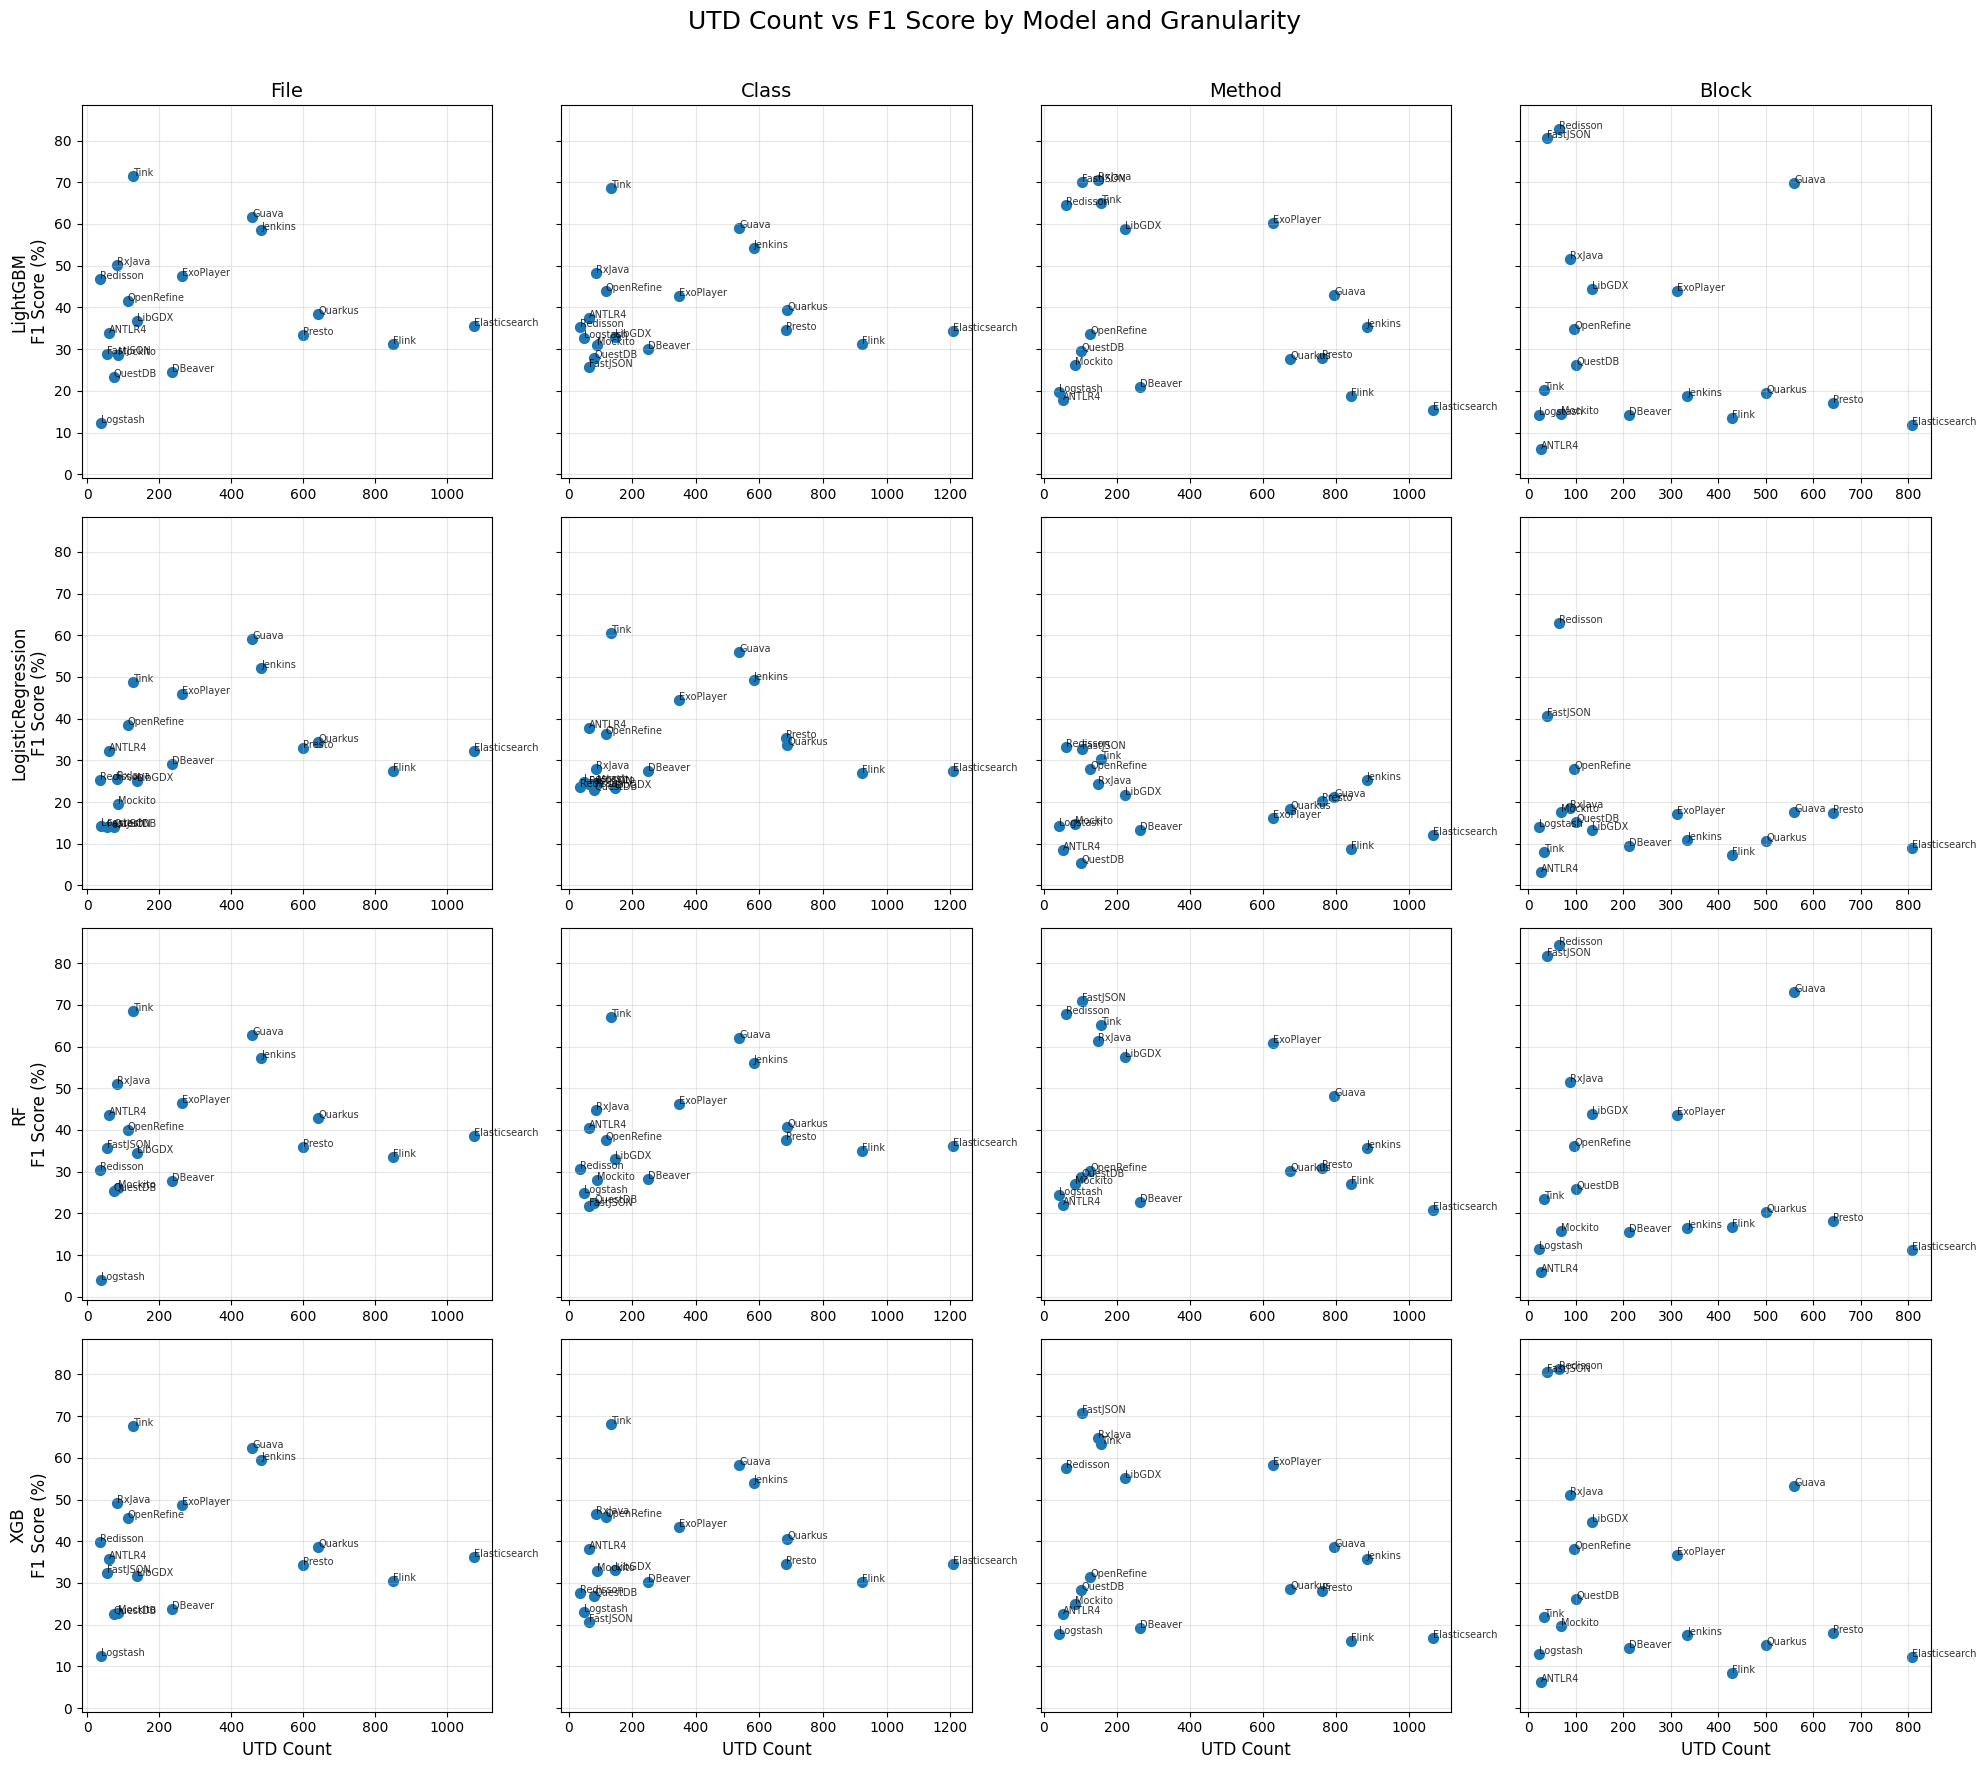

In [ ]:
import matplotlib.pyplot as plt
import re

# Order of rows and columns
models = ["LightGBM", "LogisticRegression", "RF", "XGB"]
granularities = ["file", "class", "method", "block"]

# Function to convert LaTeX percentage strings to floats
def parse_percent(s):
    s = s.replace("\\enspace", "")
    s = s.replace("\\%", "")
    return float(re.sub(r"\s+", "", s))

fig, axes = plt.subplots(
    nrows=len(models),
    ncols=len(granularities),
    figsize=(20, 18),
    sharex=False,
    sharey=True
)

for i, model in enumerate(models):
    for j, granularity in enumerate(granularities):

        ax = axes[i, j]

        counts_dict = project_utd_counts_dict_by_granularity[granularity]
        scores_dict = results_dict[model][granularity]

        # Keep projects in the same order
        projects = list(counts_dict.keys())

        x = [counts_dict[p] for p in projects]
        y = [parse_percent(scores_dict[p]) for p in projects]

        ax.scatter(x, y, s=50)

        # Optional: label each point
        for xx, yy, project in zip(x, y, projects):
            ax.annotate(
                project,
                (xx, yy),
                fontsize=7,
                alpha=0.8
            )

        if i == 0:
            ax.set_title(granularity.capitalize(), fontsize=14)

        if j == 0:
            ax.set_ylabel(f"{model}\nF1 Score (%)", fontsize=12)

        if i == len(models) - 1:
            ax.set_xlabel("UTD Count", fontsize=12)

        ax.grid(alpha=0.3)

fig.suptitle("UTD Count vs F1 Score by Model and Granularity", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()